# Large Language Models (LLMs) for Text Classification Benchmark

**Author:** Alireza Mirzadeh  
**Project:** LLM Text Classification Benchmark  
**Dataset:** Rotten Tomatoes (Hugging Face Datasets)  
**Notebook:** 03 — Transformer Models 

---

## Project Overview

This project provides a comprehensive benchmark of text classification techniques, progressing from classical machine learning methods to transformer-based models and large language models (LLMs). The implementation emphasizes reproducibility, modular software design, and rigorous experimental evaluation.

### Project Links

- **GitHub Repository:** *[llm-text-classification-benchmark](https://github.com/Alireza-Mirzadeh/llm-text-classification-benchmark)*

- **LinkedIn:** *[Alireza Mirzadeh](https://www.linkedin.com/in/alireza-mirzadeh/)*

---

# Transformer-based text classification

## Objective


In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
from src.data_loader import RottenTomatoesDataLoader

import pandas as pd
import matplotlib.pyplot as plt

from src.models.hf_pipeline_classifier import HuggingFacePipelineClassifier
from src.evaluation import evaluate_classifier, plot_confusion_matrix


# 0- Data Preparation

In [3]:
# Load the Rotten Tomatoes dataset using the data_loader from the src
loader = RottenTomatoesDataLoader()

dataset = loader.load_dataset_local()

# Create train, validation, and test splits
train_ds = dataset["train"]
validation_ds = dataset["validation"]
test_ds = dataset["test"]

# Convert to pands DataFrames
train_df = train_ds.to_pandas()
validation_df = validation_ds.to_pandas()
test_df = test_ds.to_pandas()

print(f"Train dataset shape: {train_df.shape}")
print(f"Validation dataset shape: {validation_df.shape}")
print(f"Test dataset shape: {test_df.shape}")


2026-07-12 12:39:29,095 - INFO - Loading dataset from local_path: /home/alireza/Work/llm-text-classification-benchmark/data/raw/rotten_tomatoes


Train dataset shape: (8530, 2)
Validation dataset shape: (1066, 2)
Test dataset shape: (1066, 2)


In [4]:
# Display class distribution for each split
for split_name, split_df in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}.items():
    print(
        f"{split_name.capitalize()} dataset class distribution: \n\n{split_df['label'].value_counts(normalize=True)}\n"
    )


Train dataset class distribution: 

label
1    0.5
0    0.5
Name: proportion, dtype: float64

Validation dataset class distribution: 

label
1    0.5
0    0.5
Name: proportion, dtype: float64

Test dataset class distribution: 

label
1    0.5
0    0.5
Name: proportion, dtype: float64



# 1- Task-specific Sentiment Model

Model:
cardiffnlp/twitter-roberta-base-sentiment-latest

In [5]:
# Load congifuration
config = loader.config

# Initialize the HuggingFacePipelineClassifier with the specified model name, batch size, and device from the configuration
model = HuggingFacePipelineClassifier(
    model_name=config["models"]["task_specific"]["model_name"],
    batch_size=config["models"]["task_specific"]["batch_size"],
    device=config["models"]["task_specific"]["device"],
)

# Initialize the model (this will load the pre-trained model and tokenizer)
model.fit()

2026-07-12 12:39:29,162 - INFO - Loading Hugging Face pipeline for model: cardiffnlp/twitter-roberta-base-sentiment-latest
2026-07-12 12:39:29,484 - INFO - HTTP Request: HEAD https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-12 12:39:29,499 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/cardiffnlp/twitter-roberta-base-sentiment-latest/3216a57f2a0d9c45a2e6c20157c20c49fb4bf9c7/config.json "HTTP/1.1 200 OK"
2026-07-12 12:39:29,634 - INFO - HTTP Request: HEAD https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-07-12 12:39:29,635 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-07-12 12:39:29,745 - INFO - HTTP Request: GET https://huggingface.co/api/models/cardiffnlp/twitter-roberta-base-sentiment-latest "HTTP/1.1 200 OK"
2026-07-12 12:39:29,866 - INFO - HTTP Request: GET https://huggingface.co/api/models/cardiffnlp/twitter-roberta-base-sentiment-latest/commits/main "HTTP/1.1 200 OK"
2026-07-12 12:39:29,908 - INFO - HTTP Request: GET https://huggingface.co/api/models/cardiffnlp/twitter-roberta-base-sentiment-latest/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-07-12 12:39:30,025 - INFO - HT

,model_name,'cardiffnlp/twitter-roberta-base-sentiment-latest'
,batch_size,32
,device,'auto'


In [6]:
# Predict on the test set
y_pred = model.predict(test_ds, verbose=True)


Predicting:   0%|          | 0/1066 [00:00<?, ?it/s]

Output: [{'label': 'positive', 'score': 0.9546052813529968}, {'label': 'neutral', 'score': 0.04023350402712822}, {'label': 'negative', 'score': 0.005161245819181204}]
Scores: {'positive': 0.9546052813529968, 'neutral': 0.04023350402712822, 'negative': 0.005161245819181204}
Prediction: 1 

Output: [{'label': 'positive', 'score': 0.8883834481239319}, {'label': 'neutral', 'score': 0.10391010344028473}, {'label': 'negative', 'score': 0.007706442382186651}]
Scores: {'positive': 0.8883834481239319, 'neutral': 0.10391010344028473, 'negative': 0.007706442382186651}
Prediction: 1 

Output: [{'label': 'negative', 'score': 0.7359192967414856}, {'label': 'neutral', 'score': 0.24242673814296722}, {'label': 'positive', 'score': 0.021653952077031136}]
Scores: {'negative': 0.7359192967414856, 'neutral': 0.24242673814296722, 'positive': 0.021653952077031136}
Prediction: 0 

Output: [{'label': 'positive', 'score': 0.9342907667160034}, {'label': 'neutral', 'score': 0.06267116218805313}, {'label': 'negati

In [7]:
# Inspect the predictions with a DataFrame containing the text, true labels, and predicted labels
y_pred_df = pd.DataFrame({"text": test_ds["text"], "true_label": test_ds["label"], "predicted_label": y_pred})
y_pred_df

,text,true_label,predicted_label
0,lovingly photographed in the manner of a golde...,1,1
1,consistently clever and suspenseful .,1,1
2,"it's like a "" big chill "" reunion of the baade...",1,0
3,the story gives ample opportunity for large-sc...,1,1
4,"red dragon "" never cuts corners .",1,1
...,...,...,...
1061,a terrible movie that some people will neverth...,0,0
1062,there are many definitions of 'time waster' bu...,0,0
1063,"as it stands , crocodile hunter has the hurrie...",0,0
1064,the thing looks like a made-for-home-video qui...,0,0


In [8]:
# Evaluate the model's performance on the test set using accuracy, precision, recall, and F1-score
metrics, report = evaluate_classifier(test_ds["label"], y_pred)

print("Task-Specific Transformer Sentiment Model")

for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {metric_value:.2f}")

Task-Specific Transformer Sentiment Model
accuracy: 0.80
precision: 0.86
recall: 0.72
f1: 0.78


In [9]:
# Create a DataFrame from the classification report for better visualization
report_df_sentiment_model = pd.DataFrame(report).transpose()

report_df_sentiment_model

,precision,recall,f1-score,support
negative,0.758900,0.879925,0.814944,533.000000
positive,0.857143,0.720450,0.782875,533.000000
accuracy,0.800188,0.800188,0.800188,0.800188
macro avg,0.808021,0.800188,0.798909,1066.000000
weighted avg,0.808021,0.800188,0.798909,1066.000000


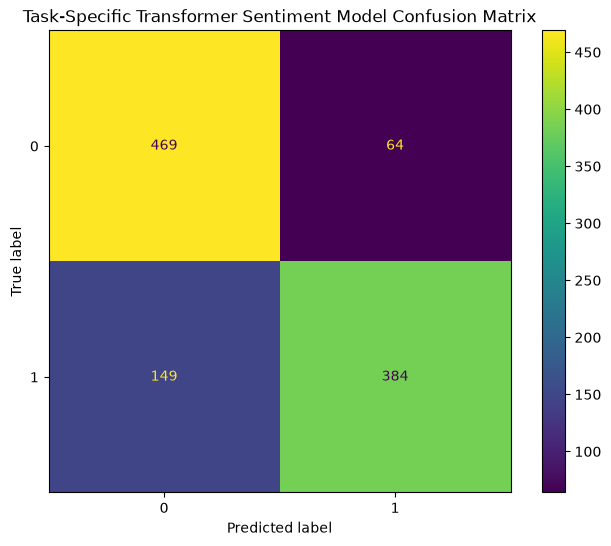

In [12]:
# Confusion matrix for the task-specific transformer sentiment model
plot_confusion_matrix("Task-Specific Transformer Sentiment Model", test_ds["label"], y_pred)

plt.show()

In [11]:
# Load benchmark results for comparison
benchmark_results_path = Path("../reports/results/benchmark_results.csv")

benchmark_df = pd.read_csv(benchmark_results_path)

results = []
results.append(
    {
        "model": "Task-Specific Transformer (cardiffnlp)",
        **metrics
    }
)
# Add the task-specific transformer model results to the benchmark results DataFrame
benchmark_df = pd.concat([benchmark_df, pd.DataFrame(results)], ignore_index=True)

# Drop the "Rank" column from the benchmark DataFrame 
benchmark_df.drop(columns=["Rank"], inplace=True)

# Sort the benchmark DataFrame by F1 score in descending order and reset the index
benchmark_df = (
    benchmark_df
    .sort_values(by="f1", ascending=False)
    .reset_index(drop=True)
)

# Set the index to start from 1 and rename the index column to "Rank"
benchmark_df.index += 1
benchmark_df.index.name = "Rank"

# Round the metrics to 3 decimal places for better readability
benchmark_df = benchmark_df.round(3)

benchmark_df

,model,accuracy,precision,recall,f1
Rank,,,,,
1,Task-Specific Transformer (cardiffnlp),0.800,0.857,0.720,0.783
2,TF-IDF + Logistic Regression,0.780,0.783,0.777,0.780
3,Bag-of-Words + Logistic Regression,0.769,0.773,0.762,0.767
4,TF-IDF + Linear SVM,0.763,0.771,0.747,0.759
5,Majority Class Baseline,0.500,0.000,0.000,0.000
